# Operational EDA — every sheet, every fleet, every week

This notebook is the **business-level** EDA that sits above the feature-engineering EDA in `stages/stage1_eda_inference.ipynb`.
It reads every sheet in `code/inputs/*.xlsx` (including `OTP`, `Heat Map`, `Regional Performance`, and `Revenue by Payer` which the phase-1 pipeline does **not** extract) and answers ten business questions — one per section.

The heavy lifting lives in `code/inference_engine/scripts/operational_eda.py` so the logic is reusable and unit-testable.
Running this notebook end-to-end rewrites:

- `code/outputs/reports/operational_eda/*.csv` — aggregated tables consumed by the `/api/v1/dashboard/*` endpoints
- `code/outputs/plots/operational_eda/*.png` — the plots embedded in `code/docs/workbooks/operational-eda.md`

Section layout:

1. Data coverage & sanity (which sheets, how many rows, Kent-Leg multiplier = 1.3)
2. Fleetwise gate scorecard (Grand Rapids vs Lansing vs Battle Creek)
3. Weekly trend (Week 1 → Week 5)
4. Mode mix & profitability (Ambulatory, Wheelchair, Stretcher, SecureCare)
5. OTP matrix (A-leg vs B-leg × region × weekday)
6. Contract volume & cancellation patterns (Gate 8 concentration, turned-down rules)
7. Hourly demand / idle windows (Heat Map)
8. Revenue by payer (lift vs the $70 Kent-Leg target)
9. Cost & margin trend (Fleet vs SecureCare + estimated regional cost)
10. Cross-view (Gate × Fleet × Week master table)

Each section writes its own CSV + PNG. The last cell prints a manifest of everything written.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'code').exists():
    REPO_ROOT = REPO_ROOT.parent
SCRIPTS = REPO_ROOT / 'code' / 'inference_engine' / 'scripts'
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

import operational_eda as ops
from IPython.display import Image, display, Markdown
import pandas as pd

REPORTS = ops.REPORTS
PLOTS = ops.PLOTS
print('Reports →', REPORTS)
print('Plots →', PLOTS)

Reports → /Users/santoshdesai/Downloads/PJTLxRideYourWay/code/outputs/reports/operational_eda
Plots → /Users/santoshdesai/Downloads/PJTLxRideYourWay/code/outputs/plots/operational_eda


## 1. Data coverage & sanity

Enumerate every sheet in every input workbook, with visible/hidden state and row/col counts. We also sanity-check the Kent-Leg multiplier that lives in cell `Heat Map!A1` (should be `1.3`).

In [2]:
ops._ensure_dirs()
result = ops.EdaResult()
coverage = ops.section_coverage(result)
display(coverage.head(25))
print('Sheets:', result.summary['sheets_total'], '(', result.summary['sheets_visible'], 'visible,',
      result.summary['sheets_hidden'], 'hidden)')

,workbook,sheet,state,max_row,max_col
0,Q1 Daily Metrics 2026.xlsx,Total Performance,visible,135.0,44.0
1,Q1 Daily Metrics 2026.xlsx,Regional Performance,visible,136.0,99.0
2,Q1 Daily Metrics 2026.xlsx,Mode Breakdown,visible,17961.0,25.0
3,Q1 Daily Metrics 2026.xlsx,OTP,visible,281.0,37.0
4,Q1 Daily Metrics 2026.xlsx,Contract Volume,visible,17929.0,39.0
5,Q1 Daily Metrics 2026.xlsx,Heat Map,visible,579.0,80.0
6,Q1 Daily Metrics 2026.xlsx,Revenue by Payer,visible,17929.0,65.0
7,Q1 Daily Metrics 2026.xlsx,Weekly Margin,visible,155.0,32.0
8,Q1 Daily Metrics 2026.xlsx,Corewell Metrics,hidden,71.0,53.0
9,Q1 Daily Metrics 2026.xlsx,Vehicle Breakdown,visible,2615.0,67.0


Sheets: 22 ( 20 visible, 2 hidden)


## 2. Fleetwise gate scorecard

The `Regional Performance` sheet carries three side-by-side regional blocks (Grand Rapids cols B–AA, Lansing cols AD–BC, Battle Creek cols BH–CF). We flatten those into long form, join in Kent-Leg / payer-concentration / non-billable-NS from `contract_volume_base.csv`, and emit a nine-gate scorecard per region.

Output: `fleet_gate_scorecard.csv` and `fleet_gate_bars.png`.

region,Battle Creek,Grand Rapids,Lansing
gate,,,
g1_vehicle_utilization,0.795968,0.848070,0.773438
g2_billed_utilization,0.878871,0.904870,0.864323
g3_volume_pool,1.260536,1.241051,1.261146
g4_rev_per_kentleg,71.855937,71.528365,81.639961
g5_higher_acuity_mix,0.001292,0.036249,0.015152
g6_nonbillable_ns,0.141816,0.216564,0.212675
g7_road_time,8.663175,8.663175,8.663175
g8_contract_concentration,0.350871,0.299646,0.156863
g8_largest_payer_rev,0.302547,0.187490,0.134845


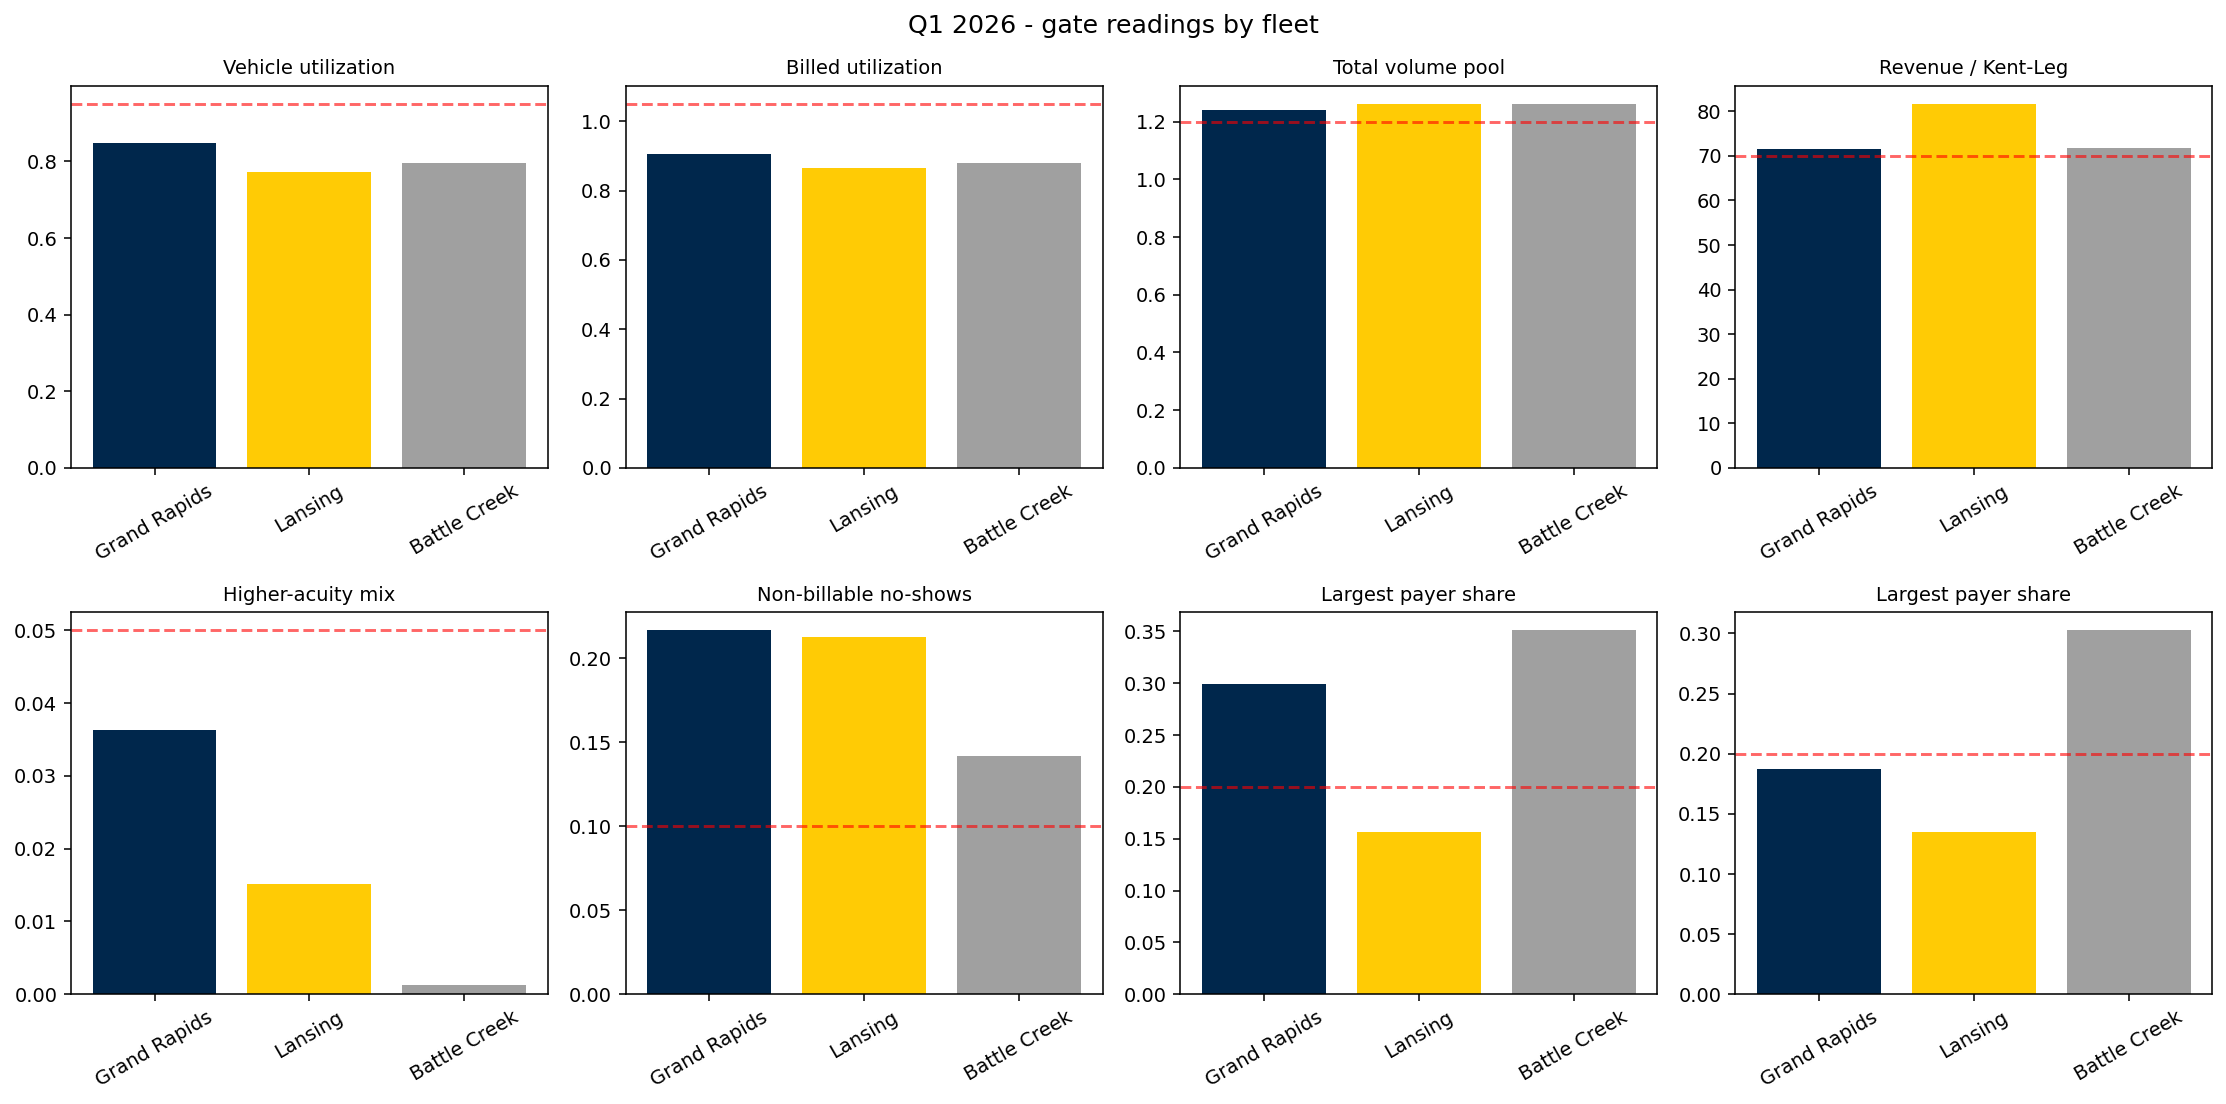

In [3]:
cv = pd.read_csv(ops.PHASE1 / 'contract_volume_base.csv')
scorecard = ops.section_fleetwise(result, cv)
display(scorecard.pivot_table(index='gate', columns='region', values='value', aggfunc='first'))
display(Image(str(PLOTS / 'fleet_gate_bars.png')))

## 3. Weekly trend (Week 1 → Week 5)

Per-week movement of every fleet-level gate plus week-over-week deltas. This is the evidence set for any claim of the form "X is improving/degrading across the quarter".

Output: `weekly_gate_trend.csv` and `weekly_trend_small_multiples.png`.

,week,vehicle_usage,billed_usage,volume_pool_ratio,revenue_per_kentleg,higher_acuity_mix,nonbillable_ns_rate,total_revenue,profit_margin
0,Week 1,0.492330,0.546951,1.243568,73.949911,0.032907,0.264545,109173.60,-0.363053
1,Week 2,0.822159,0.891023,1.272879,70.531603,0.025478,0.185474,176938.64,0.173557
2,Week 3,0.981703,1.052362,1.296556,71.017117,0.022066,0.165026,191137.44,0.233802
3,Week 4,0.818750,0.930506,1.256242,75.174173,0.030418,0.215027,165758.72,0.164646
4,Week 5,0.993788,1.081830,1.207983,73.291583,0.029805,0.193664,189549.50,0.254163


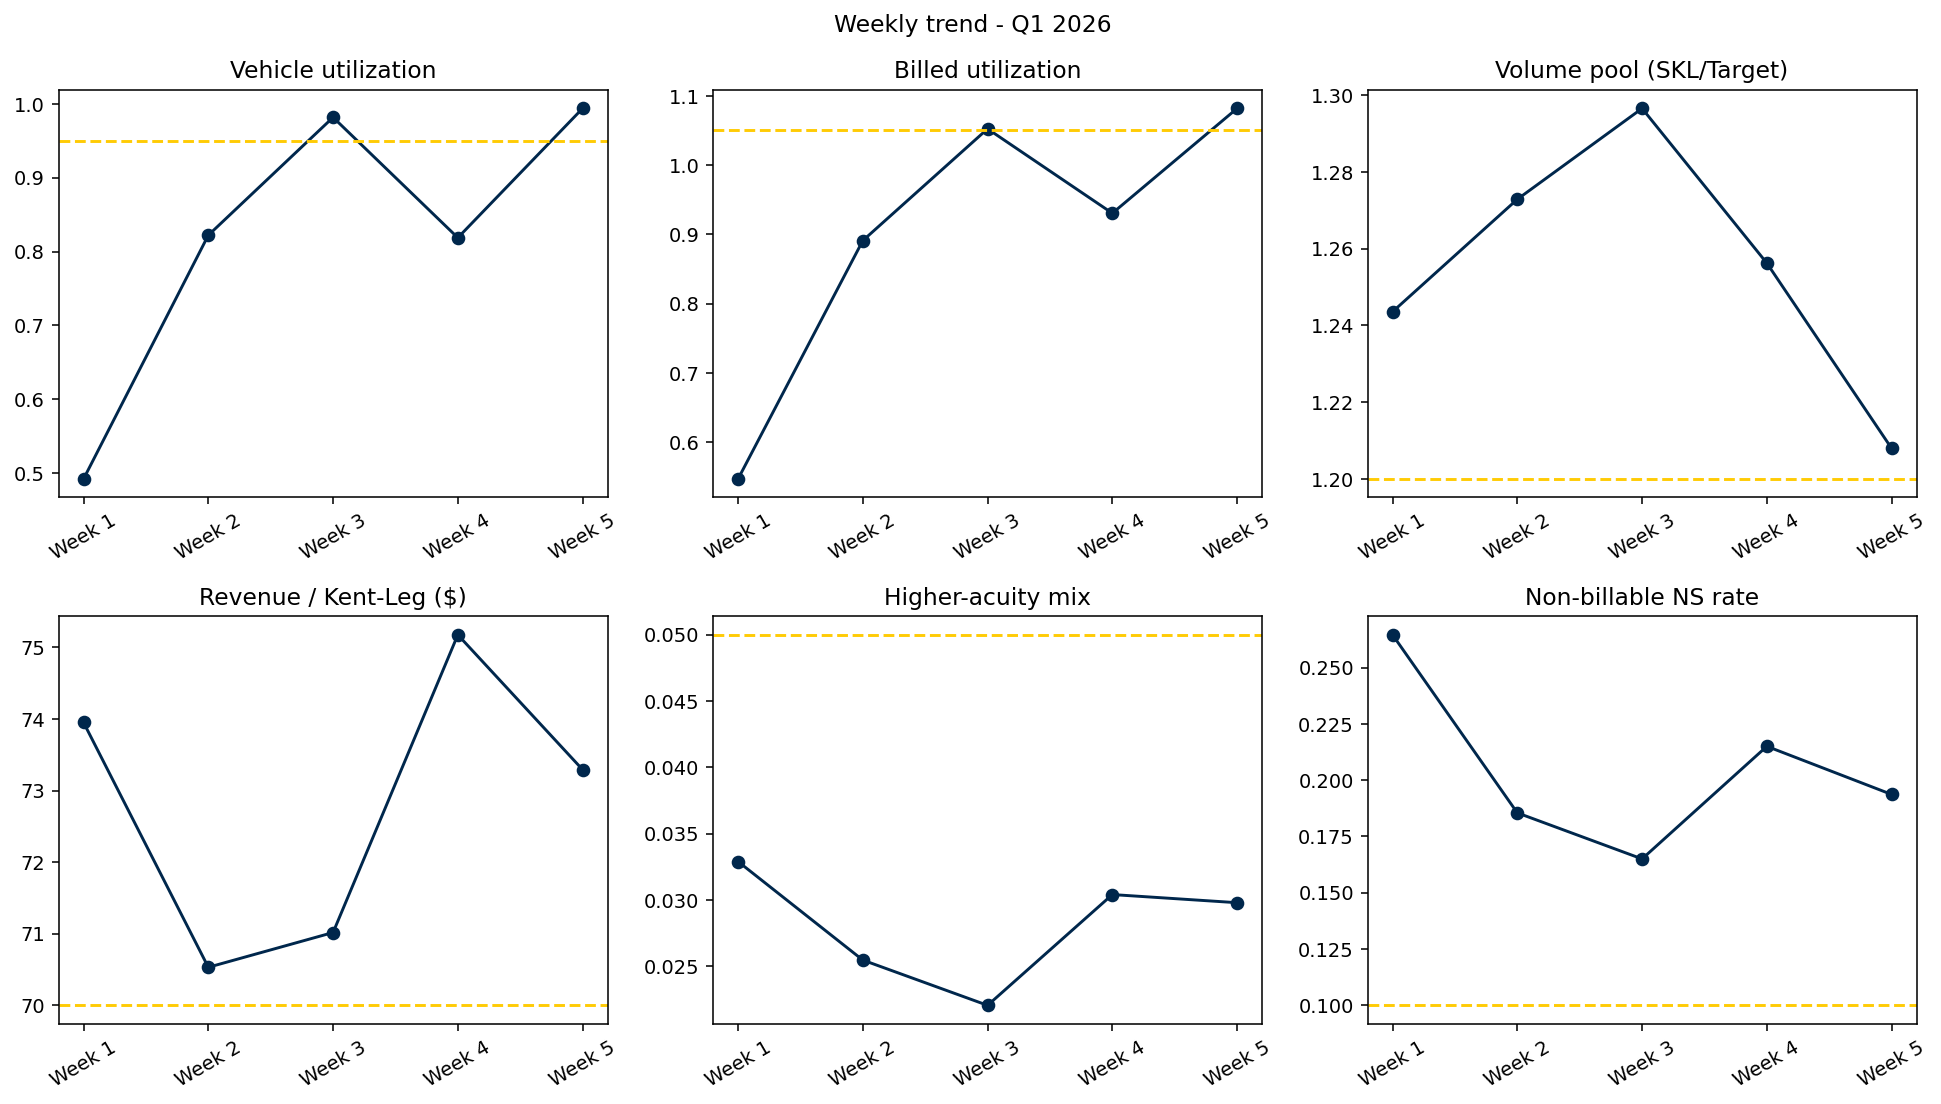

In [4]:
trend = ops.section_weekly(result, cv)
display(trend[['week', 'vehicle_usage', 'billed_usage', 'volume_pool_ratio', 'revenue_per_kentleg',
                'higher_acuity_mix', 'nonbillable_ns_rate', 'total_revenue', 'profit_margin']])
display(Image(str(PLOTS / 'weekly_trend_small_multiples.png')))

## 4. Mode mix & profitability

Per-mode share of completed trips, Kent-Leg contribution, average revenue per trip, average revenue per Kent-Leg, and no-show rates. SecureCare is reported from the dedicated `SecureCare Profit` rollup sheet (per-trip data is not in the trip log for that mode).

Output: `mode_profitability.csv` and `mode_mix.png`.

,mode,trip_count,trip_share,kent_legs,kent_leg_share,revenue,revenue_share,avg_revenue_per_trip,avg_revenue_per_kentleg,avg_miles,nonbillable_ns_rate,billable_ns_rate,profit_margin,total_cost,note
0,Wheelchair,2303.0,0.542137,2537.725714,0.479838,174985.05,0.455974,75.981350,68.953492,9.544229,0.207817,0.074357,NaN,NaN,NaN
1,Ambulatory,1828.0,0.430320,2582.750952,0.488352,152083.43,0.396298,83.196625,58.884280,16.962713,0.192256,0.020027,NaN,NaN,NaN
2,Stretcher,117.0,0.027542,168.232857,0.031810,56692.15,0.147728,484.548291,336.986193,15.037265,0.164384,0.027397,NaN,NaN,NaN
3,SecureCare,NaN,NaN,NaN,NaN,49006.82,0.127702,NaN,NaN,NaN,NaN,NaN,0.166125,40865.54,From SecureCare Profit sheet; trip log not per...


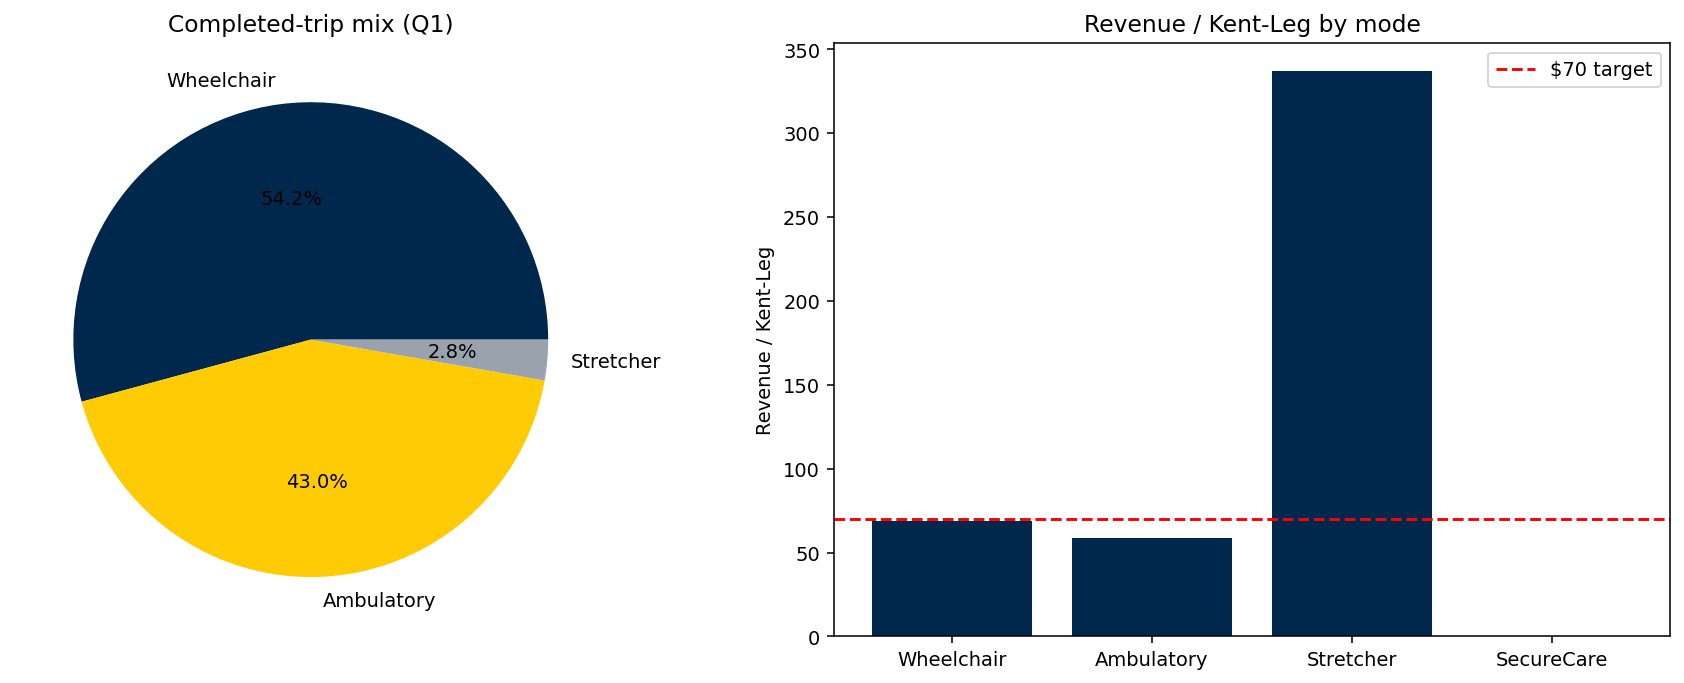

In [5]:
modes = ops.section_mode(result, cv)
display(modes)
display(Image(str(PLOTS / 'mode_mix.png')))

## 5. OTP matrix (A-leg vs B-leg × region × weekday)

The `OTP` sheet stores one block per scope (`Quarter Total`, `Week 1`..`Week 5`) with four rows per location (A on-time, A late, B on-time, B late, Mon–Fri).

Output: `otp_matrix.csv` (long form) and `otp_heatmap.png` (Q1 region × weekday heatmap).

scope                     Week 1    Week 2    Week 3    Week 4    Week 5
region       day                                                        
Grand Rapids Friday     0.888889  0.924731  0.757009  0.776596  0.094444
             Monday     0.835443  0.892157  0.945055  0.764706  0.082846
             Thursday   0.789474  0.956044  0.869159  0.742574  0.091381
             Total      0.874233  0.934959  0.877193  0.825054  0.088470
             Tuesday    0.894118  0.920792  0.950980  0.872340  0.088435
             Wednesday  0.901408  0.980952  0.877358  0.943396  0.086086
Lansing      Friday     1.000000  1.000000  0.800000  0.777778  0.092593
             Monday     0.800000  1.000000  1.000000  0.875000  0.074074
             Thursday   0.000000  1.000000  0.866667  1.000000  0.084967
             Total      0.942857  0.897959  0.946429  0.948276  0.088889
             Tuesday    1.000000  1.000000  1.000000  1.000000  0.102564
             Wednesday  1.000000  0.666667  1.000000  1.000000  0.095238
Total        Friday     0.897436  0.928571  0.758929  0.776699  0.094340
             Monday     0.831461  0.897196  0.950495  0.776316  0.081826
             Thursday   0.789474  0.961538  0.868852  0.769912  0.090502
             Total      0.880886  0.931608  0.884007  0.838772  0.088515
             Tuesday    0.905263  0.928571  0.957627  0.890909  0.090090
             Wednesday  0.912500  0.941667  0.887931  0.949580  0.087111

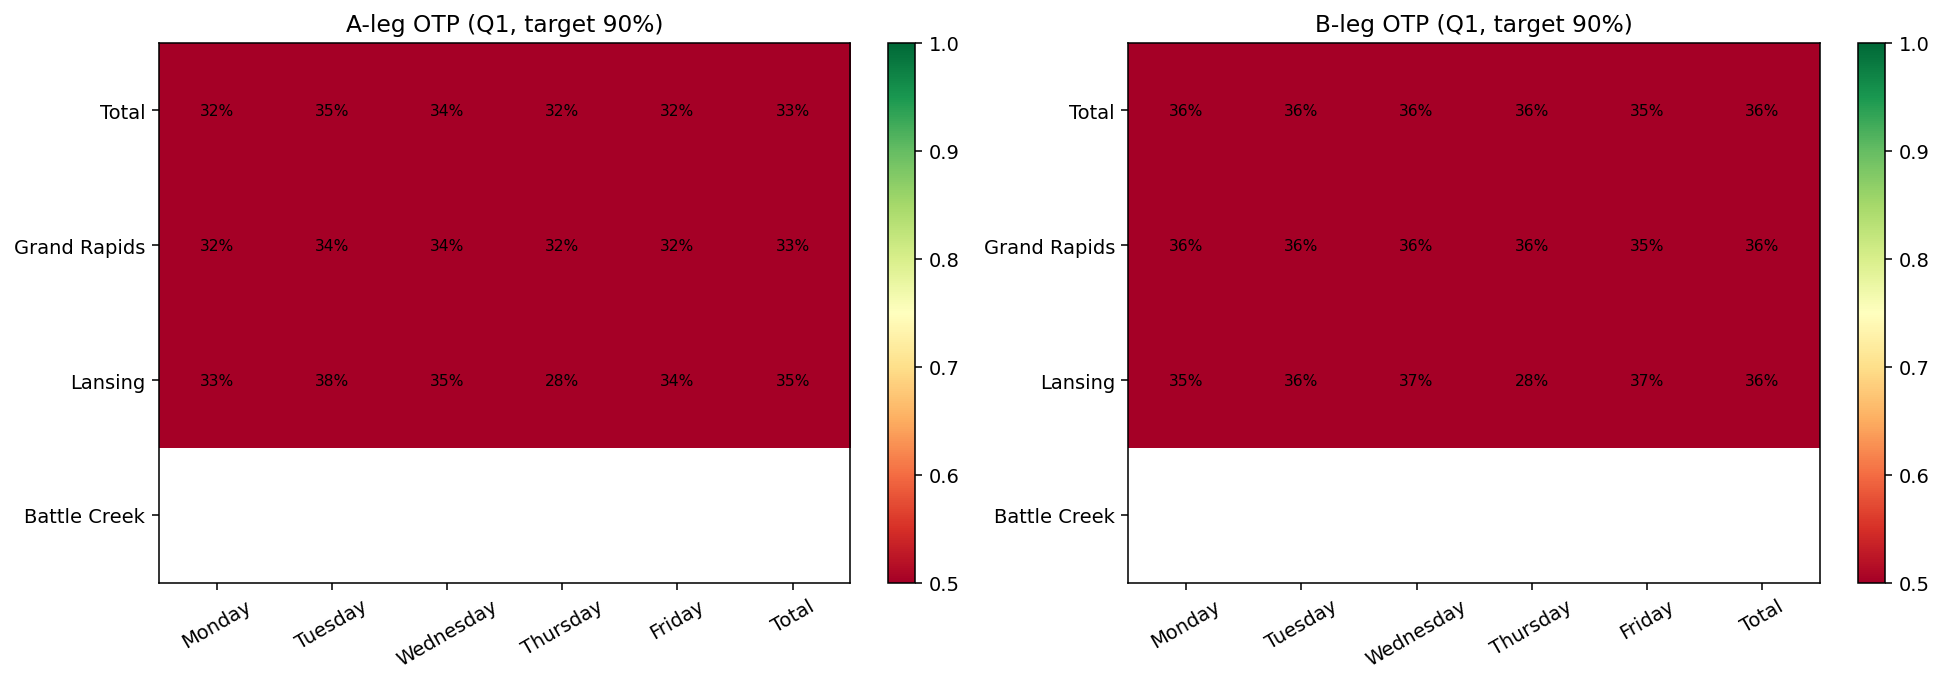

In [6]:
otp = ops.section_otp(result)
display(otp[(otp['leg'] == 'A-leg') & (otp['scope'].isin(ops.WEEK_ORDER))]
        .pivot_table(index=['region', 'day'], columns='scope', values='otp'))
display(Image(str(PLOTS / 'otp_heatmap.png')))

## 6. Contract volume & cancellation patterns (Gate 8)

Per-payer concentration against the 20% cap (Gate 8 is "no payer > 20% of volume and > 20% of revenue"), plus the breakdown of non-completed trips by `(status, reason, payer, mode, day)` — the exact pattern analysis the Internal Data Comments doc asked for ("analyze 'turned down' / 'cancelled' trips for patterns").

Outputs: `payer_concentration.csv`, `cancellation_patterns.csv`, `payer_pareto.png`, `cancellation_by_reason.png`.

Payers over 20% volume: 1
Payers over 20% revenue: 0


,payer_id,kent_legs,revenue,trips,vol_share,rev_share,over_20pct_vol,over_20pct_rev,near_cap
60,SafeRide Health - Priority Medicaid,1201.011905,54373.94,840,0.227090,0.141687,True,False,True
3,Battle Creek VA,750.571429,48243.50,641,0.141920,0.125712,False,False,False
38,MTM,659.600476,36955.82,428,0.124719,0.096299,False,False,False
70,Valley View Care Center,164.000000,31776.00,164,0.031009,0.082802,False,False,False
53,PP,303.285714,22765.00,279,0.057346,0.059321,False,False,False
47,Optalis - Muskegon,75.103333,22091.01,39,0.014201,0.057565,False,False,False
17,Corewell Health Rehab & Nursing Center-Leffing...,161.357619,10142.42,151,0.030510,0.026429,False,False,False
51,Optalis at Kent-Crossing,124.000000,9905.71,124,0.023446,0.025812,False,False,False
31,Kent County MDHHS,58.837143,9311.27,45,0.011125,0.024263,False,False,False
4,Bronson Battle Creek Hospital,62.541905,8104.38,34,0.011826,0.021118,False,False,False


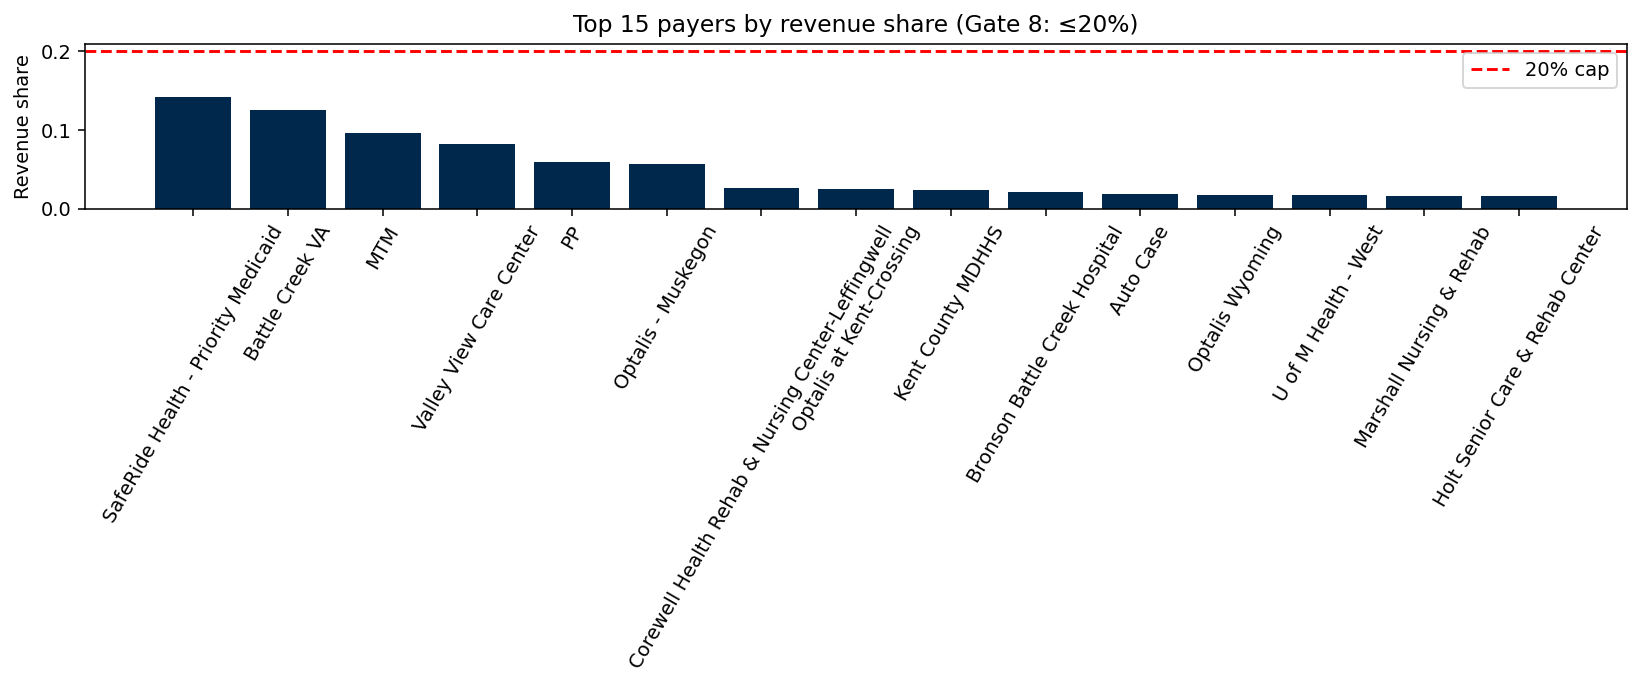

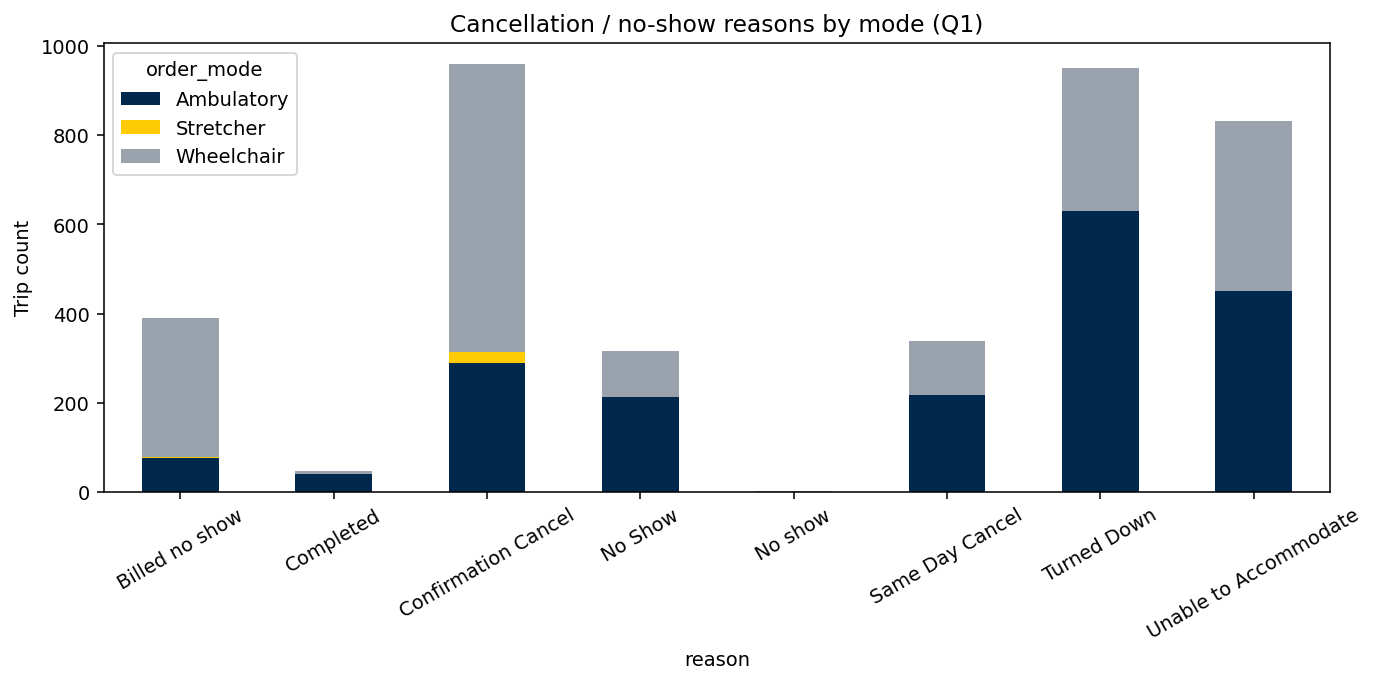

In [7]:
payer_conc, cancel = ops.section_contract_patterns(result, cv)
print('Payers over 20% volume:', result.summary['payers_over_20pct_vol'])
print('Payers over 20% revenue:', result.summary['payers_over_20pct_rev'])
display(payer_conc.head(10))
display(Image(str(PLOTS / 'payer_pareto.png')))
display(Image(str(PLOTS / 'cancellation_by_reason.png')))

## 7. Hourly demand & idle windows

The `Heat Map` sheet stacks Q4 baseline requested / completed / delivered trips by weekday × hour. We extract the first two blocks (requested vs completed) into tidy form. Any weekday business-hour cell where completed trips < 1 is flagged as an "idle window" — a candidate for redeployment or cost trimming.

Output: `hourly_demand_idle.csv` and `hourly_heatmap.png`.

Business-hour idle cells: 1


day,Friday,Monday,Saturday,Thursday,Total,Tuesday,Wednesday
metric,,,,,,,
completed,1042.6,1028.3,141.7,1010.1,5580.9,1172.6,1185.6
requested,1377.7,1346.2,180.4,1383.6,7501.1,1591.9,1618.0


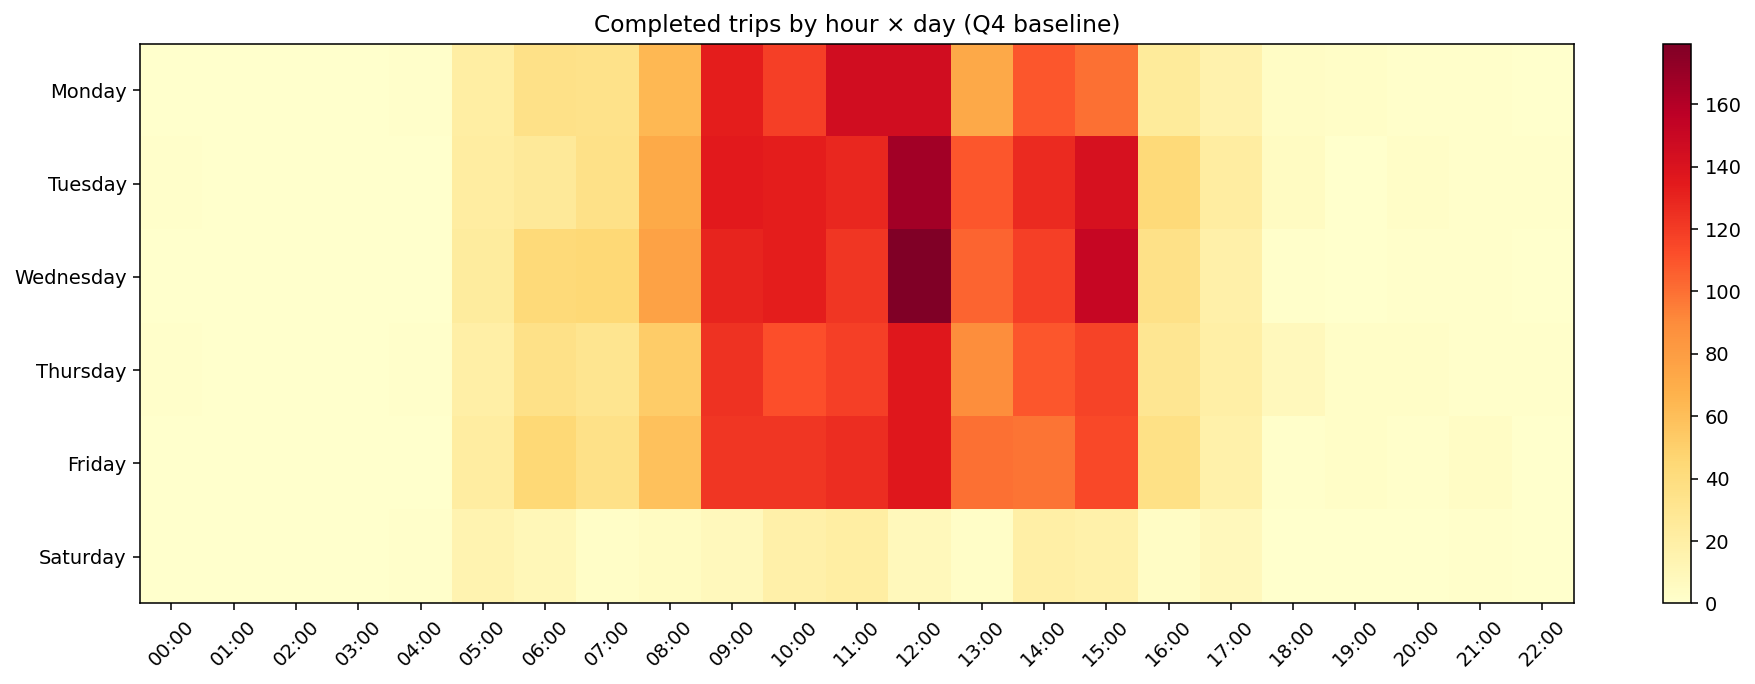

In [8]:
heatmap = ops.section_heatmap(result)
print('Business-hour idle cells:', result.summary['idle_windows_business'])
display(heatmap.groupby(['metric', 'day'])['value'].sum().unstack())
display(Image(str(PLOTS / 'hourly_heatmap.png')))

## 8. Revenue per Kent-Leg by payer

Which payers lift the fleet above the $70/Kent-Leg target, which drag it down? The waterfall plot ranks the top 20 payers by volume and colors each bar by `rev_per_KL − 70`.

Outputs: `payer_rev_per_kentleg.csv` (per payer), `payer_rev_per_kentleg_by_mode.csv` (per payer × mode), `payer_rev_waterfall.png`.

Fleet Q1 revenue / Kent-Leg: 72.56


,payer_id,revenue,kent_legs,trips,revenue_per_kentleg,lift_vs_70
60,SafeRide Health - Priority Medicaid,54373.94,1201.011905,840,45.273440,-24.726560
3,Battle Creek VA,48243.50,750.571429,641,64.275695,-5.724305
38,MTM,36955.82,659.600476,428,56.027582,-13.972418
53,PP,22765.00,303.285714,279,75.061234,5.061234
70,Valley View Care Center,31776.00,164.000000,164,193.756098,123.756098
17,Corewell Health Rehab & Nursing Center-Leffing...,10142.42,161.357619,151,62.856778,-7.143222
51,Optalis at Kent-Crossing,9905.71,124.000000,124,79.884758,9.884758
26,Harold and Grace Upjohn Community Care Center,5717.80,121.000000,121,47.254545,-22.745455
50,Optalis Wyoming,7012.00,107.000000,107,65.532710,-4.467290
2,Auto Case,7172.00,95.000000,95,75.494737,5.494737


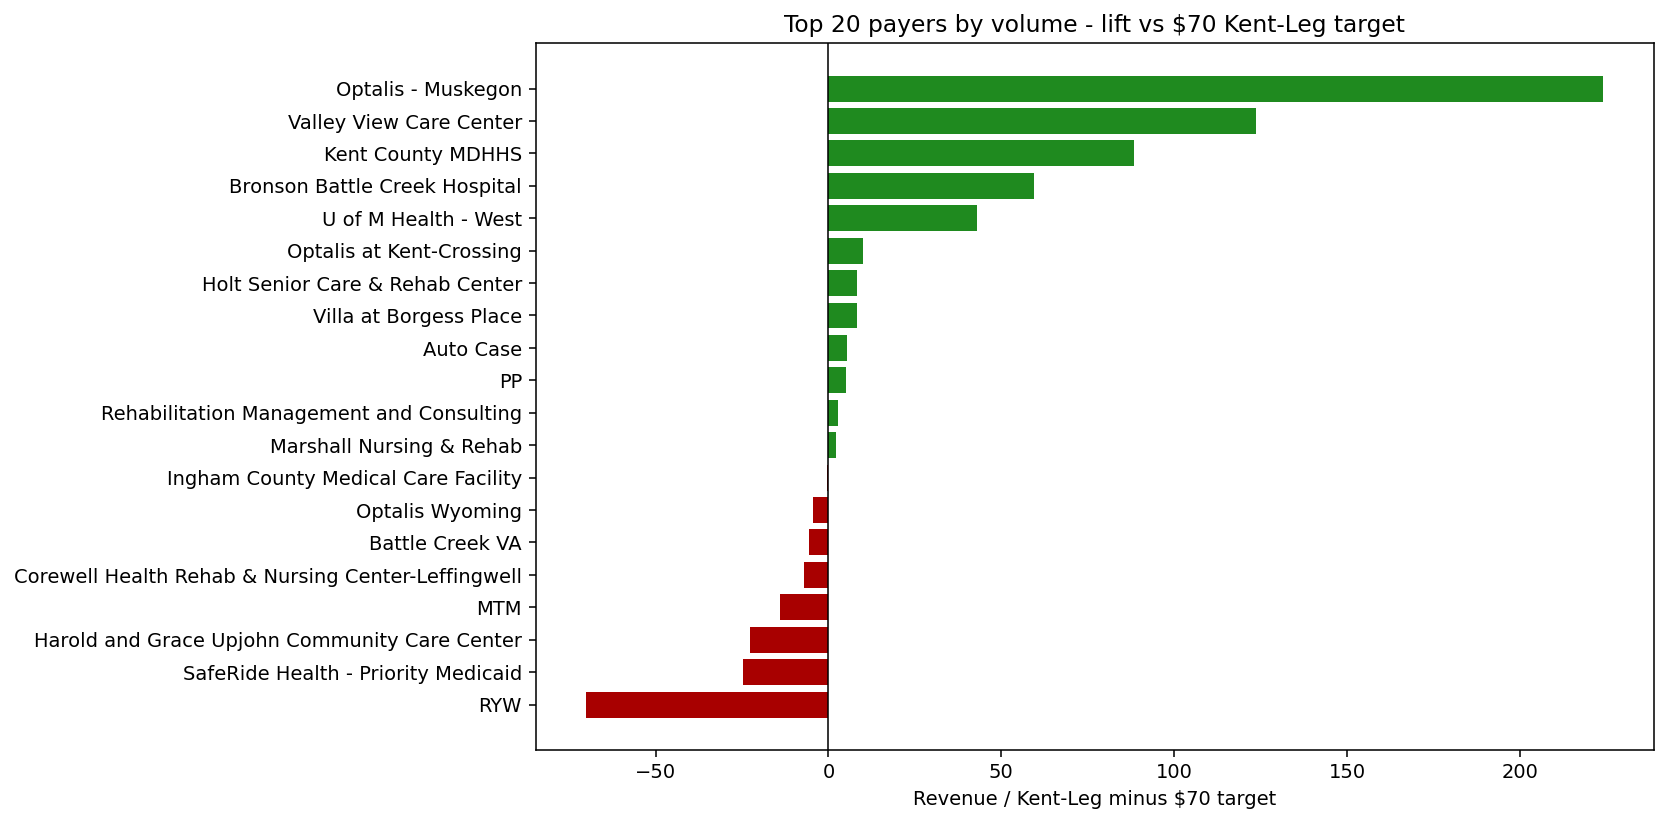

In [9]:
rev_payer = ops.section_revenue_payer(result, cv)
print('Fleet Q1 revenue / Kent-Leg:', round(result.summary['fleet_rev_per_kentleg_q1'], 2))
display(rev_payer.sort_values('kent_legs', ascending=False).head(15))
display(Image(str(PLOTS / 'payer_rev_waterfall.png')))

## 9. Cost & margin

Weekly revenue / cost / profit-margin for the fleet and for SecureCare side-by-side (`Weekly Margin` and `SecureCare Profit` sheets). Because RYW has confirmed per-region cost is **not** broken down in Q1 data, the regional cost estimate apportions fleet cost by published vehicle counts (21 GR / 4 Lansing / 5 Battle Creek). The CSV is explicitly labelled as an estimate.

Outputs: `cost_margin_trend.csv`, `regional_cost_estimate.csv`, `margin_trend.png`.

,week,stream,total_revenue,total_cost,profit_margin
0,Week 1,Fleet,109173.60,129801.06,-0.188942
1,Week 2,Fleet,176938.64,154515.28,0.126730
2,Week 3,Fleet,191137.44,154816.44,0.190026
3,Week 4,Fleet,165758.72,146674.64,0.115132
4,Week 5,Fleet,189549.50,149809.38,0.209656
5,Week 1,SecureCare,8229.00,9680.10,-0.176340
6,Week 2,SecureCare,6721.82,7683.22,-0.143027
7,Week 3,SecureCare,10870.00,7782.30,0.284057
8,Week 4,SecureCare,10587.00,7827.90,0.260612
9,Week 5,SecureCare,12599.00,7873.68,0.375055


,region,vehicle_count,cost_share_assumed,estimated_cost,estimated_road_hours,estimated_cost_per_road_hour,note
0,Grand Rapids,21,0.700000,515734.891000,4681.579972,110.162572,Estimate; RYW has not broken cost down per reg...
1,Lansing,4,0.133333,98235.217333,891.729519,110.162572,Estimate; RYW has not broken cost down per reg...
2,Battle Creek,5,0.166667,122794.021667,1114.661898,110.162572,Estimate; RYW has not broken cost down per reg...


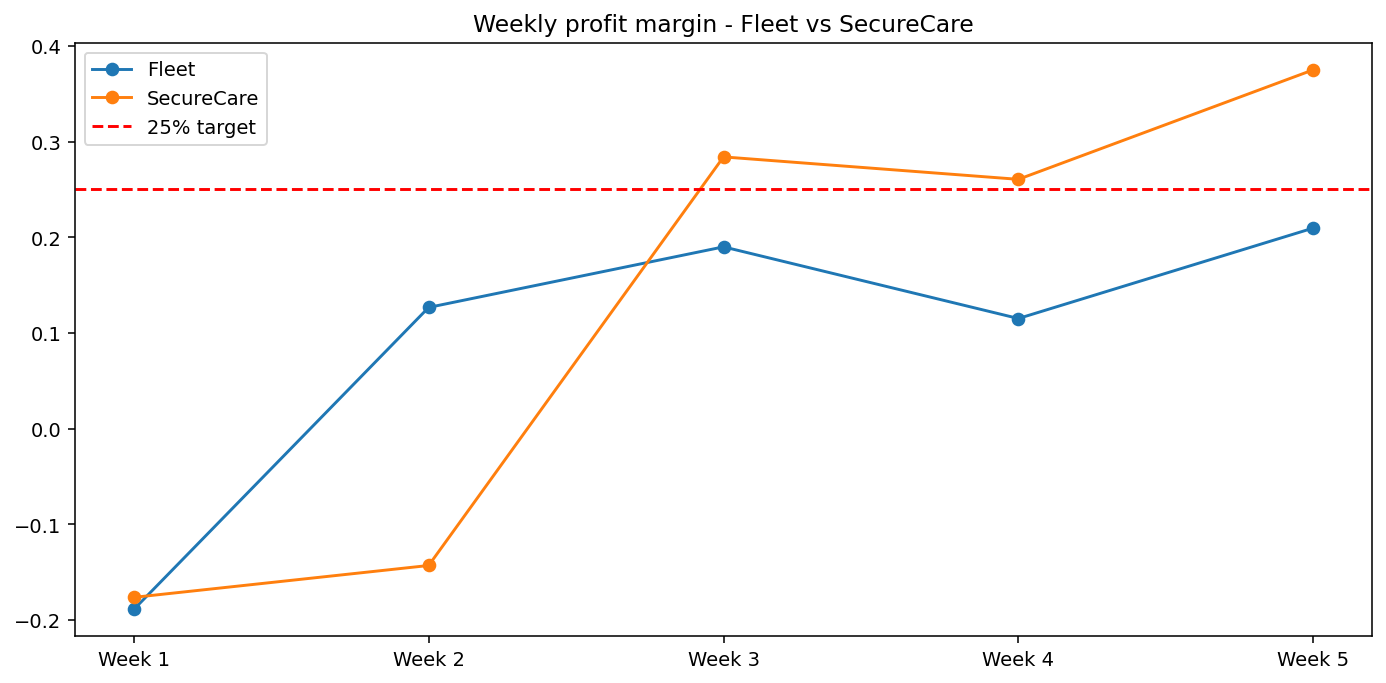

In [10]:
cost_trend, regional_cost = ops.section_cost_margin(result)
display(cost_trend)
display(regional_cost)
display(Image(str(PLOTS / 'margin_trend.png')))

## 10. Cross-view — Gate × Fleet × Week

The master table. Every row is a `(region, week)` pair with all seven quantified gates attached. It is the one-shot answer to "is any region degrading on any gate over time" and the data source for the cross-fleet heatmaps in the dashboard.

Output: `gate_fleet_week_crossview.csv` and `gate_fleet_week_heatmap.png`.

,region,week,vehicle_utilization,billed_utilization,total_pool,otp,total_rides,kent_legs,revenue_per_kentleg,higher_acuity_mix
0,Grand Rapids,Week 1,0.561364,0.597727,733.0,0.896,398.0,494.0,73.910001,0.045685
1,Lansing,Week 1,0.531250,0.593750,100.0,0.756,59.0,68.0,80.527290,0.000000
2,Battle Creek,Week 1,0.384375,0.449375,242.0,0.896,92.0,123.0,73.366295,0.000000
3,Grand Rapids,Week 2,0.935227,0.994318,1146.0,0.944,659.0,823.0,70.607085,0.033435
4,Lansing,Week 2,0.812500,0.917500,212.0,0.924,98.0,130.0,75.616939,0.020408
5,Battle Creek,Week 2,0.718750,0.761250,425.0,0.944,185.0,230.0,68.094293,0.000000
6,Grand Rapids,Week 3,1.007609,1.063587,1319.0,0.902,744.0,927.0,68.672497,0.025921
7,Lansing,Week 3,0.887500,0.937500,244.0,0.944,103.0,142.0,83.644248,0.019608
8,Battle Creek,Week 3,1.050000,1.156000,456.0,0.902,166.0,210.0,72.875161,0.006173
9,Grand Rapids,Week 4,0.781250,0.863393,1026.0,0.868,577.0,700.0,73.966009,0.043243


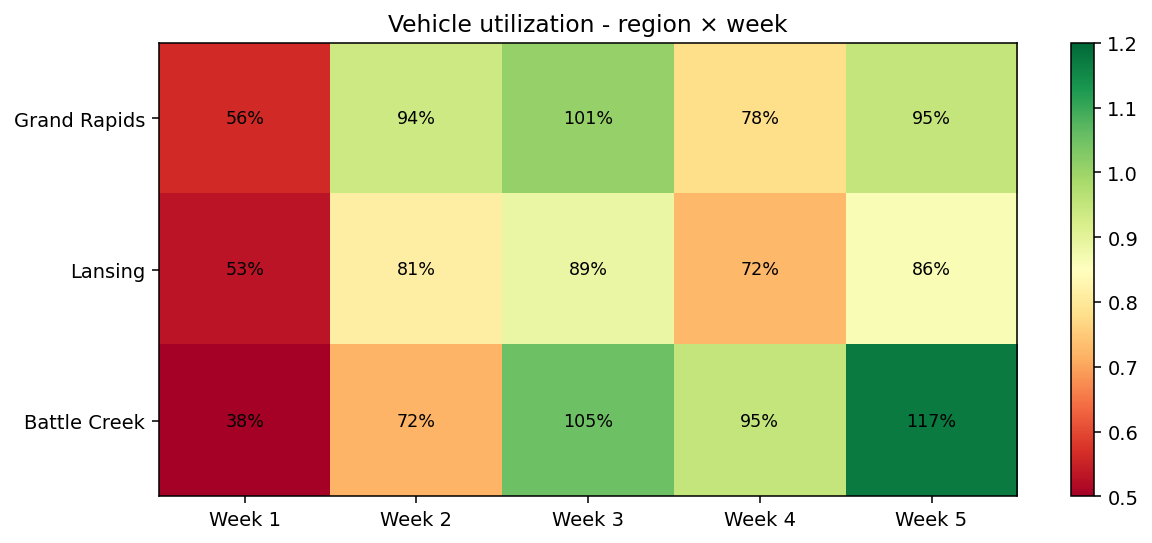

In [11]:
cross = ops.section_crossview(result, cv)
display(cross)
display(Image(str(PLOTS / 'gate_fleet_week_heatmap.png')))

## Manifest

Writes the artifact manifest used by both the narrative doc and the backend loader.

In [12]:
import json
manifest = {
    'csv_artifacts': [str(p) for p in result.csvs],
    'plot_artifacts': [str(p) for p in result.plots],
    'summary': result.summary,
}
manifest_path = REPORTS / 'manifest.json'
manifest_path.write_text(json.dumps(manifest, indent=2, default=str))
print('Wrote', manifest_path.relative_to(ops.REPO_ROOT))
print('CSVs:', len(result.csvs), '| Plots:', len(result.plots))
display(Markdown('### Summary stats'))
for k, v in result.summary.items():
    print(f'  - {k}: {v}')

Wrote code/outputs/reports/operational_eda/manifest.json
CSVs: 13 | Plots: 10


### Summary stats

  - sheets_total: 22
  - sheets_visible: 20
  - sheets_hidden: 2
  - fleet_q1_vehicle_utilization: 0.8058250866296017
  - fleet_q1_billed_utilization: 0.8826879076095699
  - fleet_q1_volume_pool_ratio: 1.2542445994675295
  - weeks_covered: 5
  - modes_analyzed: 4
  - otp_rows: 756
  - payers_total: 72
  - payers_over_20pct_vol: 1
  - payers_over_20pct_rev: 0
  - idle_windows_business: 1
  - fleet_rev_per_kentleg_q1: 72.5622438275968
  - total_cost_q1: 736764.13
  - total_road_hours_q1: 6687.971388888889
